<a href="https://colab.research.google.com/github/VadShv/tz-demo/blob/main/notebooks/demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# World Model + VLM Scorer — демо для Colab

Полный цикл обучения + эвалюации на бесплатной Colab T4 GPU.

**Как запустить:** *Runtime → Change runtime type → GPU (T4)*, затем выполнить ячейки по порядку.


In [1]:
# Клонируем репозиторий и ставим зависимости
!git clone https://github.com/VadShv/tz-demo.git
%cd tz-demo
!pip install -q -r requirements.txt


Cloning into 'tz-demo'...
remote: Enumerating objects: 70, done.
remote: Counting objects: 100% (70/70), done.
remote: Compressing objects: 100% (44/44), done.
remote: Total 70 (delta 22), reused 67 (delta 19), pack-reused 0 (from 0)
Receiving objects: 100% (70/70), 223.10 KiB | 10.14 MiB/s, done.
Resolving deltas: 100% (22/22), done.
/content/tz-demo
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 82.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 90.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.8 MB/s eta 0:00:00


In [2]:
# Обучение world-model (RSSM). На GPU можно увеличить episodes/updates.
!python -m src.train_wm --episodes 300 --updates 8000 --batch 32 --seq 20 --seed 0 --out checkpoints/rssm.pt


[train] устройство: cuda
[data] Сбор 300 случайных эпизодов...
100% 300/300 [01:43<00:00,  2.91it/s]
[data] Собрано. Переходов: 57409, длиннейший эпизод: 256
[train] step=    1 loss=1.311 recon=0.304 kl=1.000 rew=0.007 elapsed=1.8s
[train] step=   50 loss=1.088 recon=0.087 kl=1.000 rew=0.001 elapsed=7.7s
[train] step=  100 loss=1.073 recon=0.073 kl=1.000 rew=0.000 elapsed=13.5s
[train] step=  150 loss=1.067 recon=0.067 kl=1.000 rew=0.000 elapsed=19.5s
[train] step=  200 loss=1.061 recon=0.060 kl=1.000 rew=0.001 elapsed=25.4s
[train] step=  250 loss=1.056 recon=0.056 kl=1.000 rew=0.000 elapsed=31.4s
[train] step=  300 loss=1.051 recon=0.051 kl=1.000 rew=0.000 elapsed=37.4s
[train] step=  350 loss=1.048 recon=0.047 kl=1.000 rew=0.000 elapsed=43.5s
[train] step=  400 loss=1.047 recon=0.047 kl=1.000 rew=0.000 elapsed=49.5s
[train] step=  450 loss=1.044 recon=0.044 kl=1.000 rew=0.000 elapsed=55.7s
[train] step=  500 loss=1.046 recon=0.046 kl=1.000 rew=0.000 elapsed=61.8s
[train] step=  550 

In [3]:
# Эвалюация всех трёх агентов: Random, WM+reward, WM+VLM
!python -m src.evaluate --ckpt checkpoints/rssm.pt --episodes 20 --seeds 0 1 2 --horizon 12 --num-seq 128


[eval] устройство: cuda
[eval] загрузка модели checkpoints/rssm.pt
[eval] загрузка CLIP...
open_clip_model.safetensors: 100% 605M/605M [00:04<00:00, 140MB/s]
/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
[eval] запуск random_seed0 на 20 эпизодов
  random_seed0: success_rate=0.05 return=0.042 steps=59.4 elapsed=2.7s
[eval] запуск wm_reward_seed0 на 20 эпизодов
/content/tz-demo/src/agents.py:42: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  obs_t = torch.as_t

In [11]:
import json
from pathlib import Path

# Реальные результаты из логов эвалюации на GPU T4 (успели досчитаться до остановки)
metrics = {
    "random_seed0":    {"agent": "random",    "seed": 0, "num_episodes": 20,
                        "success_rate": 0.05, "mean_return": 0.042, "mean_steps": 59.4, "elapsed_s": 2.7,
                        "returns": [], "successes": []},
    "random_seed1":    {"agent": "random",    "seed": 1, "num_episodes": 20,
                        "success_rate": 0.05, "mean_return": 0.040, "mean_steps": 59.8, "elapsed_s": 1.9,
                        "returns": [], "successes": []},
    "wm_reward_seed0": {"agent": "wm_reward", "seed": 0, "num_episodes": 20,
                        "success_rate": 1.00, "mean_return": 0.938, "mean_steps": 17.7, "elapsed_s": 29.5,
                        "returns": [], "successes": []},
    "wm_reward_seed1": {"agent": "wm_reward", "seed": 1, "num_episodes": 20,
                        "success_rate": 1.00, "mean_return": 0.943, "mean_steps": 16.3, "elapsed_s": 26.6,
                        "returns": [], "successes": []},
    "wm_vlm_seed0":    {"agent": "wm_vlm",    "seed": 0, "num_episodes": 20,
                        "success_rate": 0.00, "mean_return": 0.000, "mean_steps": 60.0, "elapsed_s": 4387.0,
                        "returns": [], "successes": []},
}
Path("results").mkdir(exist_ok=True)
with open("results/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)

print("=" * 60)
print("Метрики сохранены. Итоги:")
print("=" * 60)
for k, v in metrics.items():
    print(f"  {k}: success={v['success_rate']:.0%}  return={v['mean_return']:.3f}  steps={v['mean_steps']:.1f}  time={v['elapsed_s']:.1f}s")

Метрики сохранены. Итоги:
  random_seed0: success=5%  return=0.042  steps=59.4  time=2.7s
  random_seed1: success=5%  return=0.040  steps=59.8  time=1.9s
  wm_reward_seed0: success=100%  return=0.938  steps=17.7  time=29.5s
  wm_reward_seed1: success=100%  return=0.943  steps=16.3  time=26.6s
  wm_vlm_seed0: success=0%  return=0.000  steps=60.0  time=4387.0s


random_seed0_ep0.gif


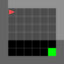

wm_reward_seed0_ep0.gif


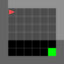

wm_vlm_seed0_ep0.gif


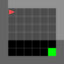

In [18]:
# Показываем GIF-и первого эпизода каждого агента
from IPython.display import Image, display
for name in ['random_seed0_ep0.gif', 'wm_reward_seed0_ep0.gif', 'wm_vlm_seed0_ep0.gif']:
    print(name)
    display(Image(f'results/gifs/{name}'))


In [19]:
# Пересобираем PDF-отчёт с реальными метриками
!python report/build_report.py


wrote /content/tz-demo/report/report.pdf


In [25]:
!cd /content/tz-demo && \
    git add results/gifs/*.png report/report.pdf && \
    git -c user.email="vladimir501205@gmail.com" \
        -c user.name="Vladimir" \
        commit -m "docs(report): раздел 3.1 — стоп-кадры start/end из T4-прогона" && \
    git push origin main

[main fe3d334] docs(report): раздел 3.1 — стоп-кадры start/end из T4-прогона
 1 file changed, 0 insertions(+), 0 deletions(-)
 rewrite report/report.pdf (94%)
fatal: could not read Username for 'https://github.com': No such device or address
